In [48]:
# Government & Policy Analysis

## To examine how policy, funding,
## and service demand impact mental health outcomes.

In [3]:
# Import file from excel

from google.colab import files
uploaded = files.upload()

Saving government_data_fixed.csv to government_data_fixed.csv


In [4]:
# Import libraries for data analysis and visualisation
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Load NHS waiting-time data
df = pd.read_csv("government_data_fixed.csv")

In [7]:
df.head ()

,Period,Total number of incomplete pathways,Median waiting time (weeks),Within 18 weeks (%)
0,March 2025,2802,8.7,76.9
1,February 2025,2974,9.7,75.9
2,January 2025,3005,9.1,76.6
3,December 2024,3088,8.9,75.6
4,November 2024,3088,8.0,74.3


In [8]:
df.tail ()

,Period,Total number of incomplete pathways,Median waiting time (weeks),Within 18 weeks (%)
31,August 2022,18476,10.1,71.9
32,July 2022,19266,9.6,74.0
33,June 2022,18552,9.1,75.9
34,May 2022,17910,9.0,77.7
35,April 2022,17485,6.7,76.8


In [9]:
# Reverse the dataset so the analysis follows a chronological timeline (2022–2025)
df = df.iloc[::-1].reset_index(drop=True)

In [10]:
# Examine trends in service backlog, waiting times,
# and performance against the NHS 18-week target

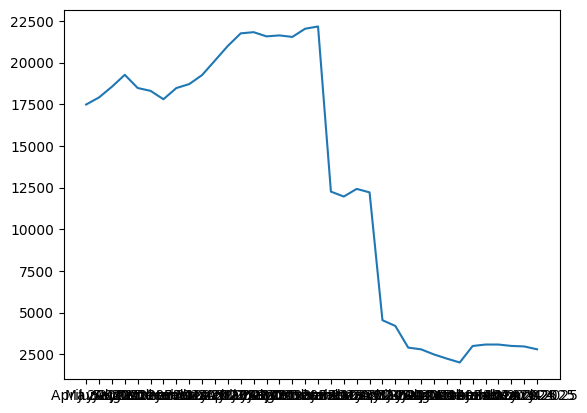

In [17]:
# Plot the total number of incomplete pathways
# This represents patients still waiting to begin treatment
plt.plot(
    df["Period"],
    df["Total number of incomplete pathways"],
    label="Incomplete Pathways" )

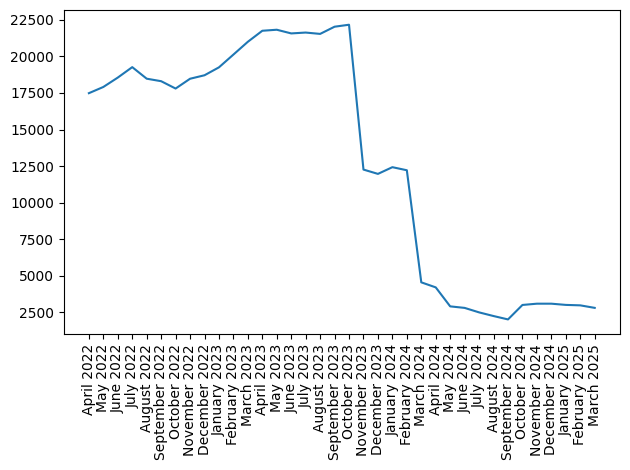

In [20]:
# Replot the total number of incomplete pathways
# Fix x-axis labels
plt.plot(
    df["Period"],
    df["Total number of incomplete pathways"],
    label="Incomplete Pathways" )
plt.xticks(rotation=90)
plt.tight_layout()

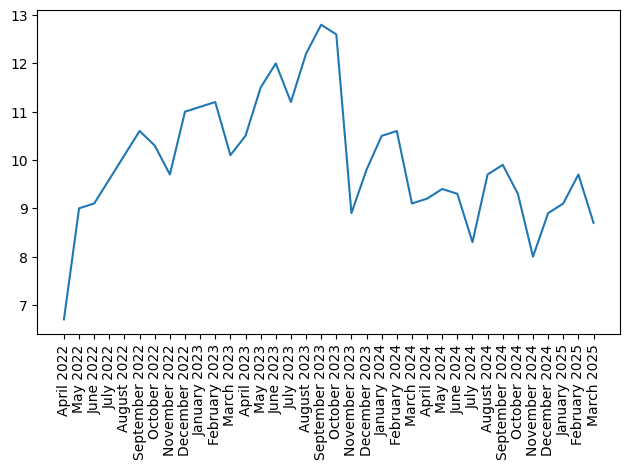

In [21]:
# Plot median waiting time
# This provides an indication of the typical patient experience
plt.plot(
    df["Period"],
    df["Median waiting time (weeks)"],
    label="Median Waiting Time"
)
plt.xticks(rotation=90)
plt.tight_layout()

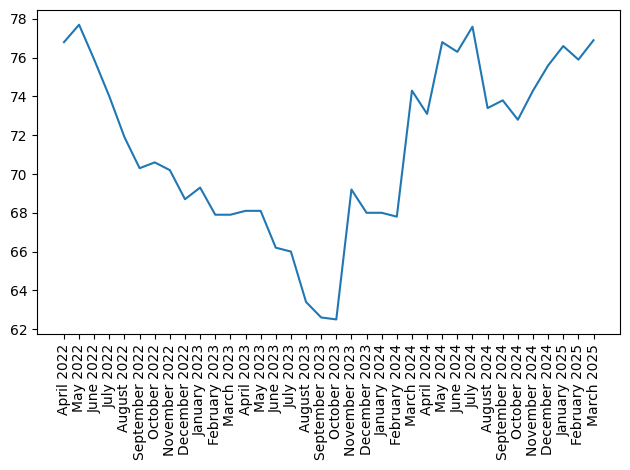

In [22]:
# Plot the percentage of patients treated within 18 weeks
# This measures performance against the NHS treatment target
plt.plot(
    df["Period"],
    df["Within 18 weeks (%)"],
    label="Within 18 Weeks (%)"
)
plt.xticks(rotation=90)
plt.tight_layout()

In [23]:
# Create normalised versions of the variables for comparison to improve spacing
df["Incomplete_Normalised"] = (
    df["Total number of incomplete pathways"] -
    df["Total number of incomplete pathways"].min()
) / (
    df["Total number of incomplete pathways"].max() -
    df["Total number of incomplete pathways"].min()
)

df["Wait_Normalised"] = (
    df["Median waiting time (weeks)"] -
    df["Median waiting time (weeks)"].min()
) / (
    df["Median waiting time (weeks)"].max() -
    df["Median waiting time (weeks)"].min()
)

df["Within18_Normalised"] = (
    df["Within 18 weeks (%)"] -
    df["Within 18 weeks (%)"].min()
) / (
    df["Within 18 weeks (%)"].max() -
    df["Within 18 weeks (%)"].min()
)

In [24]:
df.head ()
df.tail ()

,Period,Total number of incomplete pathways,Median waiting time (weeks),Within 18 weeks (%),Incomplete_Normalised,Wait_Normalised,Within18_Normalised
31,November 2024,3088,8.0,74.3,0.053389,0.213115,0.776316
32,December 2024,3088,8.9,75.6,0.053389,0.360656,0.861842
33,January 2025,3005,9.1,76.6,0.049271,0.393443,0.927632
34,February 2025,2974,9.7,75.9,0.047732,0.491803,0.881579
35,March 2025,2802,8.7,76.9,0.039198,0.327869,0.947368


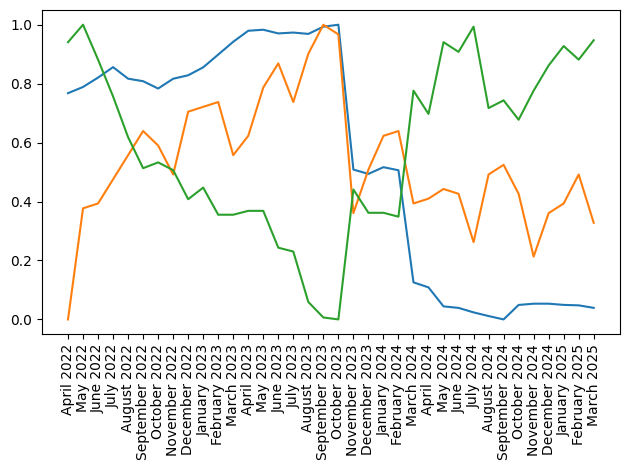

In [25]:
# Compare normalised trends over time
plt.plot(df["Period"], df["Incomplete_Normalised"], label="Incomplete Pathways")
plt.plot(df["Period"], df["Wait_Normalised"], label="Median Waiting Time")
plt.plot(df["Period"], df["Within18_Normalised"], label="Within 18 Weeks (%)")
plt.xticks(rotation=90)
plt.tight_layout()


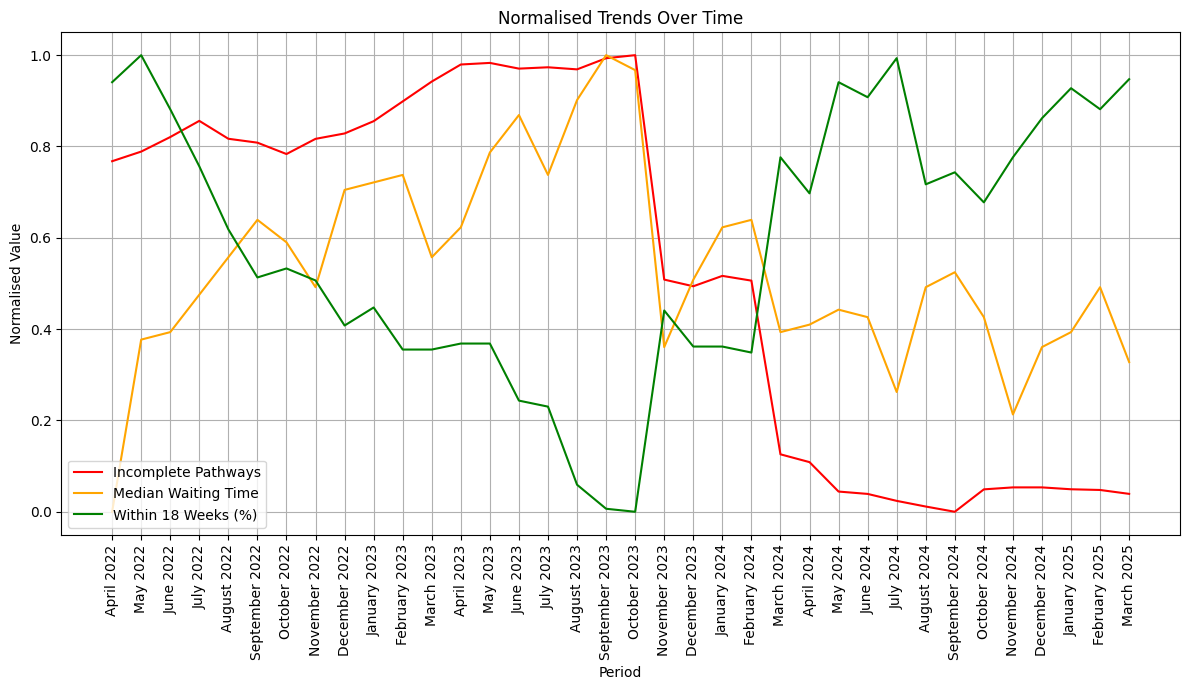

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plt.plot(df["Period"], df["Incomplete_Normalised"], label="Incomplete Pathways", color="red")
plt.plot(df["Period"], df["Wait_Normalised"], label="Median Waiting Time", color="orange")
plt.plot(df["Period"], df["Within18_Normalised"], label="Within 18 Weeks (%)", color="green")

plt.title("Normalised Trends Over Time")
plt.xlabel("Period")
plt.ylabel("Normalised Value")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

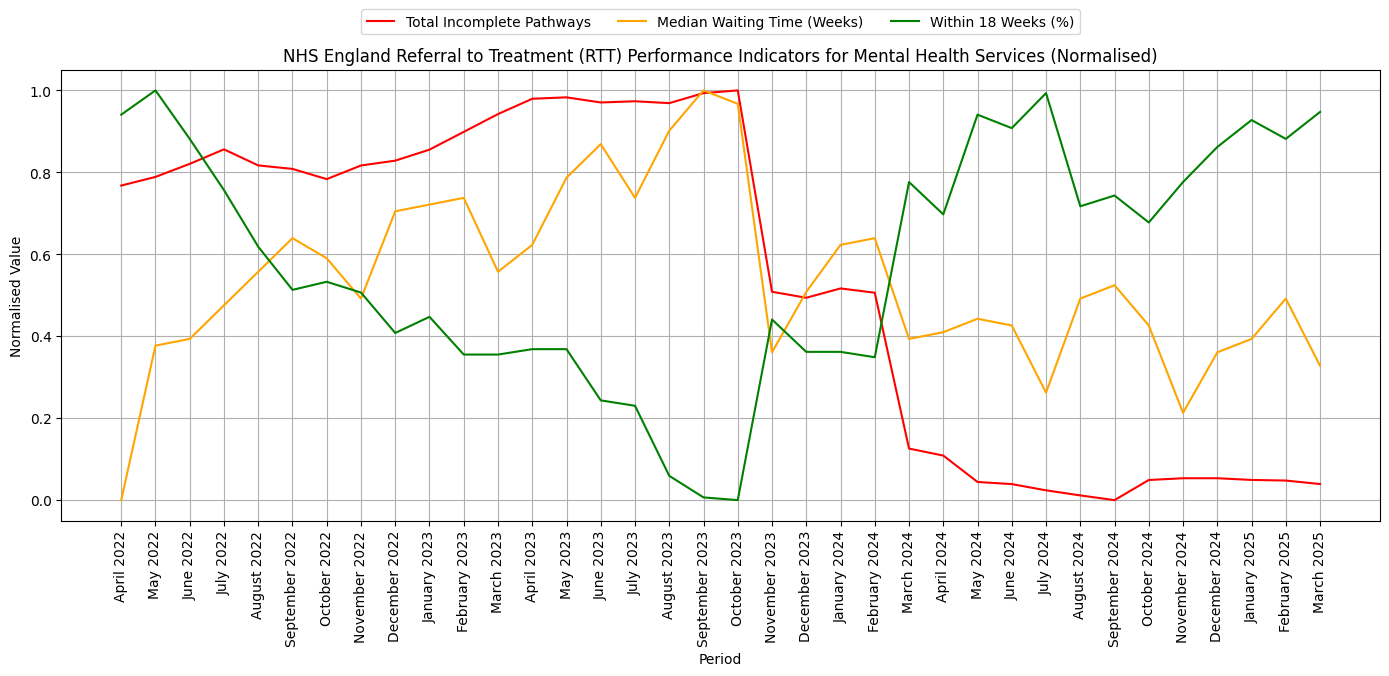

In [56]:
# Move the colour legend above the graph

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(df["Period"], df["Incomplete_Normalised"], label="Total Incomplete Pathways", color="red")
plt.plot(df["Period"], df["Wait_Normalised"], label="Median Waiting Time (Weeks)", color="orange")
plt.plot(df["Period"], df["Within18_Normalised"], label="Within 18 Weeks (%)", color="green")

plt.title("NHS England Referral to Treatment (RTT) Performance Indicators for Mental Health Services (Normalised)")
plt.xlabel("Period")
plt.ylabel("Normalised Value")
plt.xticks(rotation=90)
plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=3
)
plt.grid(True)
plt.tight_layout()
plt.show()